# 02 - Exploratory analysis

Describes the data before any estimator is applied. Nothing here is causal; the aim is to
see the structure that the design has to contend with.

1. Levels and trends by state, and why raw counts need normalising.
2. Treated versus never-treated cohort means.
3. The east/west split, which is close to collinear with treatment (`DESIGN.md` 5.1).
4. Event-time alignment around fee introduction.
5. The raw NRW and Hessen drops that motivated the study, shown without a counterfactual.

In [8]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "processed" / "panel.parquet").exists():
            return cand
    raise FileNotFoundError("panel.parquet not found. Run: py src/build_panel.py")

ROOT = find_root()
sys.path.insert(0, str(ROOT))
FIG = ROOT / "results" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
TAB = ROOT / "results" / "tables";  TAB.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

panel = pd.read_parquet(ROOT / "data" / "processed" / "panel.parquet")

INTRO_WINDOW_END = 2007   # last winter semester before the first abolition (Hessen, WS 2008/09)
OUTCOME = "first_years_location"

print(f"{len(panel)} rows | {panel.state.nunique()} states | "
      f"{panel.year.min()}-{panel.year.max()}")
print(f"introduction window: {panel.year.min()}-{INTRO_WINDOW_END} "
      f"({INTRO_WINDOW_END - panel.year.min() + 1} winter semesters)")

448 rows | 16 states | 1998-2025
introduction window: 1998-2007 (10 winter semesters)


## 1. Levels differ enormously across states

State size spans more than an order of magnitude, so raw counts are dominated by how big a
state is. Difference-in-differences removes fixed level differences by construction, but
for plotting and for any pooled mean the series must be indexed.

In [9]:
sizes = (panel[panel.year == 2005]
         .set_index("state")[OUTCOME].sort_values(ascending=False))
print("first-years in WS 2005/06 (last pre-treatment semester):")
print(sizes.to_string())
print(f"\nlargest / smallest: {sizes.max() / sizes.min():.1f}x")

first-years in WS 2005/06 (last pre-treatment semester):
state
Nordrhein-Westfalen       67786
Bayern                    45809
Baden-Wuerttemberg        39979
Hessen                    25000
Niedersachsen             22250
Sachsen                   18316
Berlin                    15840
Rheinland-Pfalz           12152
Thueringen                 8553
Hamburg                    8416
Sachsen-Anhalt             7806
Schleswig-Holstein         6853
Brandenburg                6840
Mecklenburg-Vorpommern     5700
Bremen                     5129
Saarland                   3410

largest / smallest: 19.9x


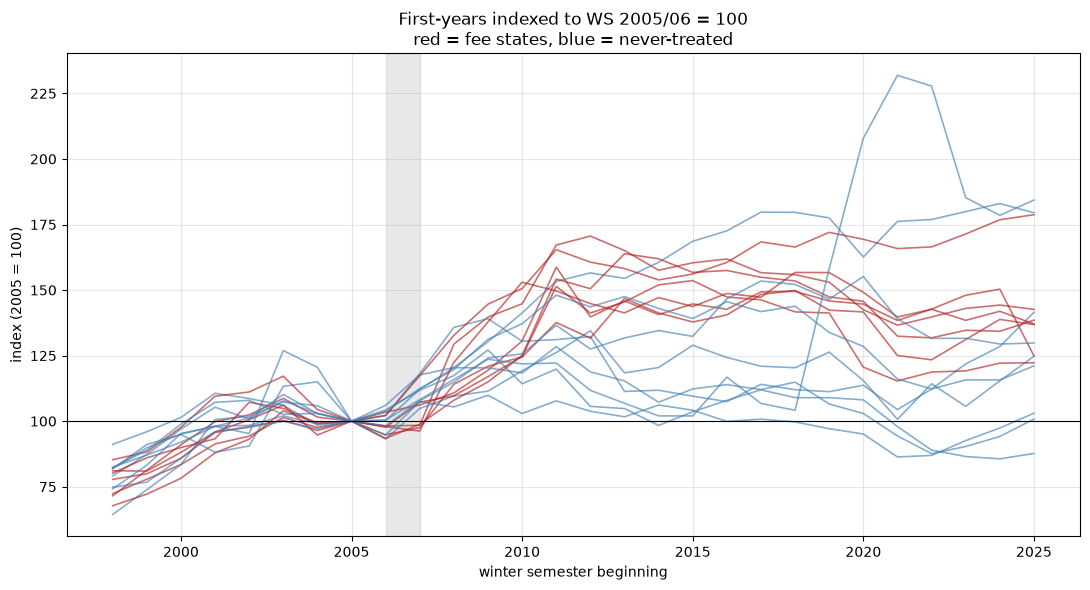

In [10]:
# index each state to its own 2005 level so trajectories are comparable
base = (panel[panel.year == 2005].set_index("state_code")[OUTCOME])
panel["idx_2005"] = panel[OUTCOME] / panel["state_code"].map(base) * 100

fig, ax = plt.subplots(figsize=(11, 6))
for st, g in panel.groupby("state"):
    treated_ever = g["ever_treated"].iloc[0] == 1
    ax.plot(g["year"], g["idx_2005"],
            color="firebrick" if treated_ever else "steelblue",
            alpha=0.65, lw=1.2)
ax.axhline(100, color="black", lw=0.8)
ax.axvspan(2006, INTRO_WINDOW_END, color="grey", alpha=0.18)
ax.set_title("First-years indexed to WS 2005/06 = 100\n"
             "red = fee states, blue = never-treated")
ax.set_xlabel("winter semester beginning"); ax.set_ylabel("index (2005 = 100)")
plt.tight_layout()
plt.savefig(FIG / "03_indexed_trajectories.png", dpi=130, bbox_inches="tight")
plt.show()

## 2. Cohort means

Population-weighted mean for fee states against never-treated states. The shaded band is
the introduction window. This is the picture difference-in-differences formalises: what
matters is whether the two lines were moving in parallel *before* the band.

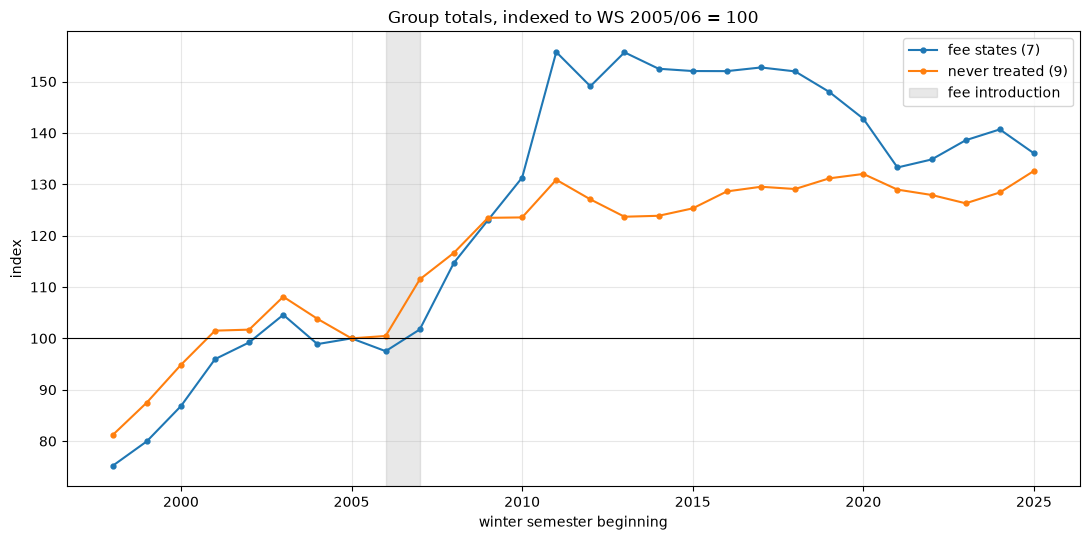

group  fee states (7)  never treated (9)      gap
year                                             
1998             75.2               81.2     -6.0
1999             80.0               87.5     -7.5
2000             86.8               94.8     -8.0
2001             96.0              101.5     -5.5
2002             99.2              101.7     -2.5
2003            104.6              108.1     -3.5
2004             98.9              103.8     -4.9
2005            100.0              100.0      0.0
2006             97.5              100.5     -3.0
2007            101.7              111.5     -9.7
2008            114.7              116.7     -2.0
2009            123.0              123.5     -0.4
2010            131.3              123.5      7.7
2011            155.8              130.9     24.9
2012            149.1              127.1     22.0


In [11]:
grp = panel.assign(group=np.where(panel.ever_treated == 1, "fee states (7)",
                                  "never treated (9)"))
cohort = (grp.groupby(["group", "year"], as_index=False)[OUTCOME].sum())
first = cohort[cohort.year == 2005].set_index("group")[OUTCOME]
cohort["idx"] = cohort[OUTCOME] / cohort["group"].map(first) * 100

fig, ax = plt.subplots()
for g, d in cohort.groupby("group"):
    ax.plot(d["year"], d["idx"], marker="o", ms=3.5, label=g)
ax.axhline(100, color="black", lw=0.8)
ax.axvspan(2006, INTRO_WINDOW_END, color="grey", alpha=0.18, label="fee introduction")
ax.set_title("Group totals, indexed to WS 2005/06 = 100")
ax.set_xlabel("winter semester beginning"); ax.set_ylabel("index")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "04_group_means.png", dpi=130, bbox_inches="tight")
plt.show()

piv = cohort.pivot(index="year", columns="group", values="idx")
piv["gap"] = piv["fee states (7)"] - piv["never treated (9)"]
print(piv.loc[1998:2012].to_string(float_format=lambda x: f"{x:8.1f}"))

**Read the gap column.** Under parallel trends it should be roughly flat before 2006.
Movement there is the first sign of trouble, and it is tested formally in notebook 03
rather than judged by eye here.

## 3. East and west

Every treated state is western and six of the nine never-treated states are eastern
(`DESIGN.md` 5.1), so the comparison is partly an east-west comparison. If the two regions
were on different trajectories in this period, that difference maps onto the treatment
indicator.

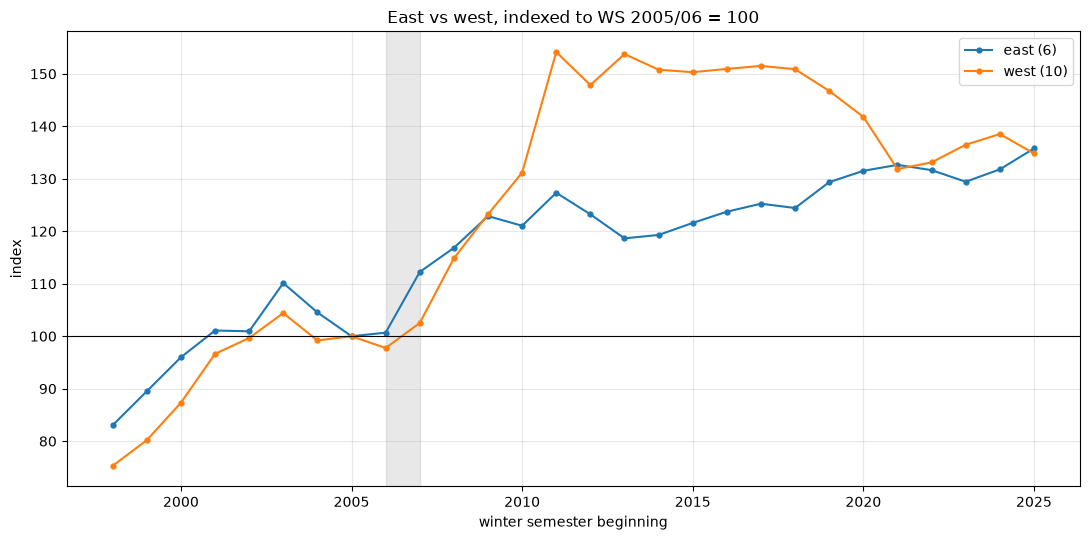

never-treated states by region:
  east: Berlin, Brandenburg, Mecklenburg-Vorpommern, Sachsen, Sachsen-Anhalt, Thueringen
  west: Bremen, Rheinland-Pfalz, Schleswig-Holstein   <- the western-only comparison group


In [12]:
reg = panel.assign(region=np.where(panel.east == 1, "east (6)", "west (10)"))
r = reg.groupby(["region", "year"], as_index=False)[OUTCOME].sum()
b = r[r.year == 2005].set_index("region")[OUTCOME]
r["idx"] = r[OUTCOME] / r["region"].map(b) * 100

fig, ax = plt.subplots()
for g, d in r.groupby("region"):
    ax.plot(d["year"], d["idx"], marker="o", ms=3.5, label=g)
ax.axhline(100, color="black", lw=0.8)
ax.axvspan(2006, INTRO_WINDOW_END, color="grey", alpha=0.18)
ax.set_title("East vs west, indexed to WS 2005/06 = 100")
ax.set_xlabel("winter semester beginning"); ax.set_ylabel("index")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "05_east_west.png", dpi=130, bbox_inches="tight")
plt.show()

print("never-treated states by region:")
nt = panel[panel.cohort == 0][["state", "east"]].drop_duplicates()
print(f"  east: {', '.join(sorted(nt[nt.east == 1].state))}")
print(f"  west: {', '.join(sorted(nt[nt.east == 0].state))}   <- the western-only comparison group")

## 4. Event-time alignment

Each fee state aligned on its own introduction semester, so the two cohorts (2006 and 2007)
are directly comparable. Never-treated states have no event time and are excluded here.

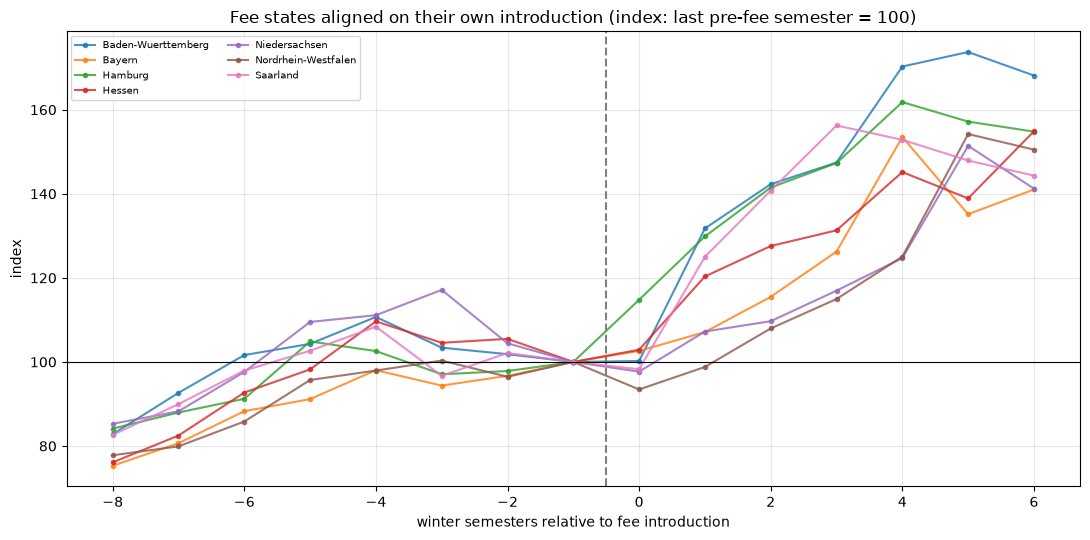

In [13]:
ev = panel[(panel.cohort > 0) & panel.event_time.between(-8, 6)].copy()
b = ev[ev.event_time == -1].set_index("state_code")[OUTCOME]
ev["idx_m1"] = ev[OUTCOME] / ev["state_code"].map(b) * 100

fig, ax = plt.subplots()
for st, g in ev.groupby("state"):
    ax.plot(g["event_time"], g["idx_m1"], marker="o", ms=3, alpha=0.8, label=st)
ax.axvline(-0.5, color="grey", ls="--")
ax.axhline(100, color="black", lw=0.8)
ax.set_title("Fee states aligned on their own introduction (index: last pre-fee semester = 100)")
ax.set_xlabel("winter semesters relative to fee introduction"); ax.set_ylabel("index")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(FIG / "06_event_time_alignment.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. The raw drops that motivated the question

Contemporary reporting noted first-year falls in Nordrhein-Westfalen and Hessen as fees
came in. Those are shown here **without a counterfactual**, which is exactly their
limitation: many things move enrolment at once, and a single state's before-and-after
cannot separate them.

In [14]:
for st in ["Nordrhein-Westfalen", "Hessen"]:
    g = panel[(panel.state == st) & panel.year.between(2003, 2010)].copy()
    g["yoy_%"] = g[OUTCOME].pct_change() * 100
    print(f"\n{st} (intro {int(g.intro_year.iloc[0])}):")
    print(g[["year", "term_label", OUTCOME, "yoy_%", "treated"]]
          .to_string(index=False, float_format=lambda x: f"{x:8.1f}"))


Nordrhein-Westfalen (intro 2006):
 year term_label  first_years_location    yoy_%  treated
 2003 WS 2003/04                 68009      NaN        0
 2004 WS 2004/05                 65389     -3.9        0
 2005 WS 2005/06                 67786      3.7        0
 2006 WS 2006/07                 63346     -6.6        1
 2007 WS 2007/08                 66981      5.7        1
 2008 WS 2008/09                 73186      9.3        1
 2009 WS 2009/10                 77933      6.5        1
 2010 WS 2010/11                 84761      8.8        1

Hessen (intro 2007):
 year term_label  first_years_location    yoy_%  treated
 2003 WS 2003/04                 25984      NaN        0
 2004 WS 2004/05                 24777     -4.6        0
 2005 WS 2005/06                 25000      0.9        0
 2006 WS 2006/07                 23698     -5.2        0
 2007 WS 2007/08                 24386      2.9        1
 2008 WS 2008/09                 28518     16.9        0
 2009 WS 2009/10               

## What this notebook establishes

### 1. State size spans 20x, so nothing can be compared in raw counts

Nordrhein-Westfalen enrolled 67,786 first-years in WS 2005/06; Saarland 3,410. Every
comparison here is indexed, and the estimators absorb the level differences with state
fixed effects.

### 2. The raw drops that motivated the study are real

| state | semester | change | note |
|---|---|---|---|
| Nordrhein-Westfalen | WS 2006/07 (first fee semester) | **-6.6%** | after +3.7% the year before |
| Hessen | WS 2006/07 (fees announced Oct 2006) | **-5.2%** | fees not yet charged |
| Hessen | WS 2007/08 (first fee semester) | +2.9% | weak growth |
| Hessen | WS 2008/09 (fees abolished) | **+16.9%** | |

Hessen's fall happens the semester **before** fees applied, when the law was passed. If
real, that is **anticipation**, which `DESIGN.md` 8.2 lists as a threat and which the
event-study leads test directly. It also means a specification that dates treatment to the
first charged semester understates the response.

### 3. There is a visible differential pre-trend

The gap between fee states and never-treated states (index points, 2005 = 100):

```
1998   1999   2000   2001   2002   2003   2004   2005
-6.0   -7.5   -8.0   -5.5   -2.5   -3.5   -4.9    0.0
```

This is not flat. Fee states close roughly 8 index points on the comparison group across
the pre-period, a systematic narrowing rather than noise around a constant. **This is the
political-selection threat of `DESIGN.md` 4.2 appearing in the data**: the states that
chose to introduce fees were on a different trajectory beforehand.

Two cautions on reading the numbers above. Indexing to 2005 forces the gap to zero in that
year by construction, which flatters the pre-period; and the 2007 gap (-9.7) is inflated by
Sachsen-Anhalt's double cohort in the control group (notebook 01). Neither the pre-trend
nor the apparent 2007 effect can be taken at face value from this chart. Both are tested
properly in notebook 03.

### 4. East and west diverge, but mostly after the introduction window

The two regions track each other closely until about 2008 and separate sharply afterwards.
Since the introduction window ends in 2007, most of that divergence falls outside the
primary specification, which weakens the case for restricting to the three western
never-treated states and supports keeping the pooled comparison group as the baseline. The
comparison-group choice is still decided by the power calculation in `DESIGN.md` 5.2, not
by this plot.

### Carried into notebook 03

1. Test the pre-trend formally, without the 2005 normalisation.
2. Compute the minimum detectable effect per comparison group.
3. Test for anticipation with event-study leads, given the Hessen pattern.
4. Check how much the 2007 estimate depends on Sachsen-Anhalt.

Next: `03_pretrends_power.ipynb`.